# IC-0921 — How diversified is your client, really?

**ML & FinTech · 115-1 · 20260921 · 50 minutes: 40 working, 10 discussion**

| Step | Min | What you do |
|---|---|---|
| 1 | 16 | Get to know the data, and learn the two clustering tools |
| 2 | 14 | Cluster the client's portfolio, two ways |
| 3 | 10 | Give the client advice |
| — | 10 | Discussion |

You work at a robo-advisor. A client calls:

> *"I'm well diversified. I own twelve different stocks."*

Twelve tickers is not twelve bets. If several of them rise and fall together, the client owns
fewer independent positions than he thinks. **By the end you will tell him how many bets he
actually owns.**

You may use any AI tool. It will write the code. The code is not what is graded — whether you
understand what the output means is.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

---
# Step 1 — Know your data, learn the tools (16 min)

## 1a. What the client owns

Run the cell. The table gives every ticker, the company behind it, and its industry.
**Keep this table in view for the rest of the exercise.**

In [2]:
import sys
from pathlib import Path

FILE = "historical_stock_prices_2017.csv"
IN_COLAB = "google.colab" in sys.modules

CAND = [FILE,
        f"/content/{FILE}",
        f"/content/drive/MyDrive/{FILE}",
        f"../slides/{FILE}",
        f"../00-course-info/in-class-exercise/{FILE}"]
path = next((p for p in CAND if Path(p).exists()), None)

if path is None and IN_COLAB:
    # Option A (default): upload the CSV from your computer
    from google.colab import files
    print("Select historical_stock_prices_2017.csv to upload ...")
    files.upload()
    path = FILE
    # Option B: use Google Drive instead (comment out the 3 lines above, then uncomment below)
    # from google.colab import drive
    # drive.mount("/content/drive")
    # path = f"/content/drive/MyDrive/{FILE}"

if path is None or not Path(path).exists():
    raise FileNotFoundError(f"Put {FILE} next to this notebook (or upload it in Colab).")

prices = pd.read_csv(path, index_col=0)
prices.index = pd.to_datetime(prices.index)

holdings = pd.DataFrame([
    ("BANC", "Banc of California",        "Banking"),
    ("BANF", "BancFirst Corporation",     "Banking"),
    ("GWB",  "Great Western Bancorp",     "Banking"),
    ("ISTR", "Investar Holding Corp.",    "Banking"),
    ("CAKE", "The Cheesecake Factory",    "Restaurants"),
    ("DFRG", "Del Frisco's Restaurant Gp.","Restaurants"),
    ("LOCO", "El Pollo Loco Holdings",    "Restaurants"),
    ("BREW", "Craft Brew Alliance",       "Brewing"),
    ("AAPL", "Apple Inc.",                "Technology"),
    ("EBAY", "eBay Inc.",                 "E-commerce"),
    ("QQQ",  "Invesco QQQ Trust",         "ETF, Nasdaq-100"),
    ("CCOI", "Cogent Communications",     "Telecom"),
], columns=["ticker", "company", "industry"]).set_index("ticker")

PORTFOLIO = holdings.index.tolist()
P = prices[PORTFOLIO]          # 251 trading days of 2017 x 12 stocks
print(P.shape)
holdings

Select historical_stock_prices_2017.csv to upload ...


Saving historical_stock_prices_2017.csv to historical_stock_prices_2017.csv
(251, 12)


,company,industry
ticker,,
BANC,Banc of California,Banking
BANF,BancFirst Corporation,Banking
GWB,Great Western Bancorp,Banking
ISTR,Investar Holding Corp.,Banking
CAKE,The Cheesecake Factory,Restaurants
DFRG,Del Frisco's Restaurant Gp.,Restaurants
LOCO,El Pollo Loco Holdings,Restaurants
BREW,Craft Brew Alliance,Brewing
AAPL,Apple Inc.,Technology


## 1b. Prices through the year

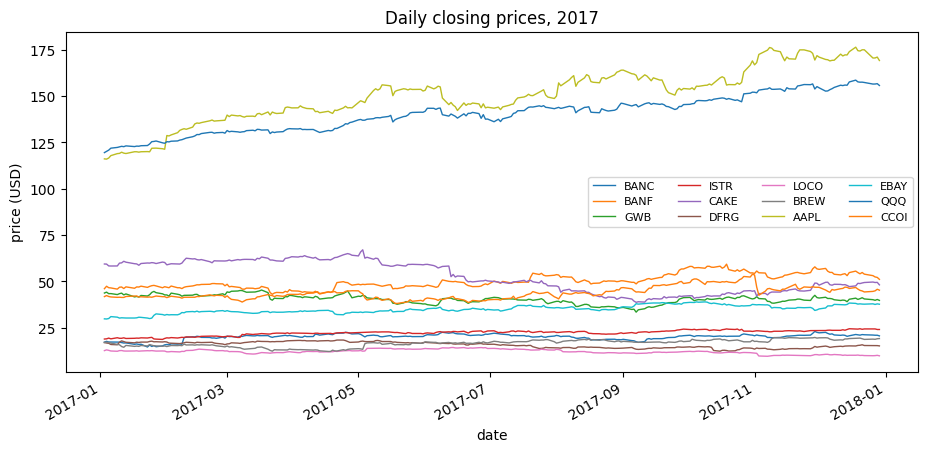

In [3]:
P.plot(figsize=(11, 5), linewidth=1)
plt.title("Daily closing prices, 2017")
plt.ylabel("price (USD)")
plt.legend(ncol=4, fontsize=8)
plt.show()

## 1c. Daily returns

Prices tell you the level. **Returns tell you the movement**, which is what risk is made of.

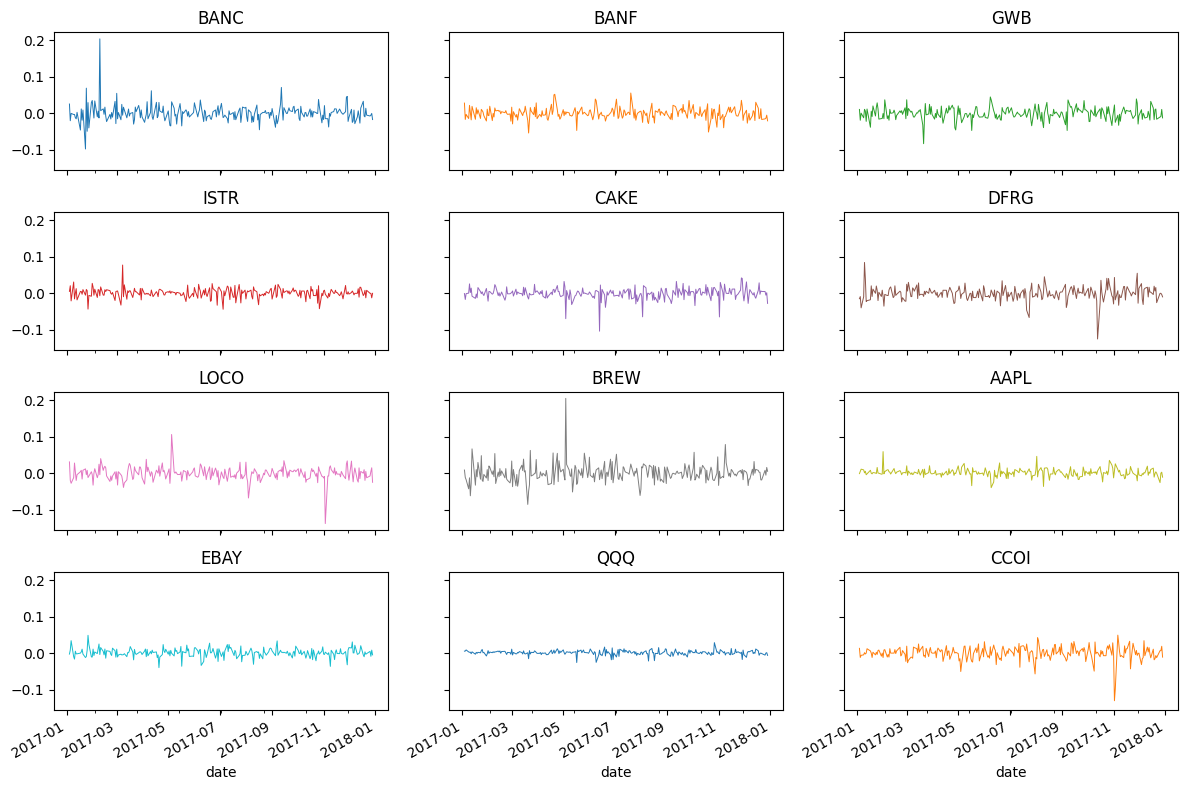

In [4]:
R = np.log(P).diff().dropna()     # daily log returns

R.plot(subplots=True, layout=(4, 3), figsize=(12, 8),
       sharey=True, legend=False, linewidth=0.7, title=list(R.columns))
plt.tight_layout()
plt.show()

## 1d. Summary statistics

In [5]:
summary = pd.DataFrame({
    "mean price":    P.mean(),
    "min price":     P.min(),
    "max price":     P.max(),
    "ann. return %": R.mean() * 252 * 100,
    "ann. vol %":    R.std() * np.sqrt(252) * 100,
}).round(1)
summary.join(holdings[["industry"]])

,mean price,min price,max price,ann. return %,ann. vol %,industry
BANC,20.1,14.6,23.0,18.1,37.4,Banking
BANF,50.2,43.1,59.3,10.5,25.4,Banking
GWB,40.5,33.5,45.4,-9.6,26.8,Banking
ISTR,22.3,18.8,24.5,24.2,21.0,Banking
CAKE,52.4,38.8,67.1,-21.2,25.9,Restaurants
DFRG,15.8,12.4,18.4,-11.2,30.5,Restaurants
LOCO,12.2,9.6,14.4,-25.1,29.5,Restaurants
BREW,16.7,12.2,19.8,11.7,41.2,Brewing
AAPL,150.6,116.0,176.4,37.9,17.6,Technology
EBAY,35.1,29.8,39.0,23.7,19.0,E-commerce


## 1e. Risk against reward

Each stock as one point: risk on the horizontal axis, reward on the vertical.

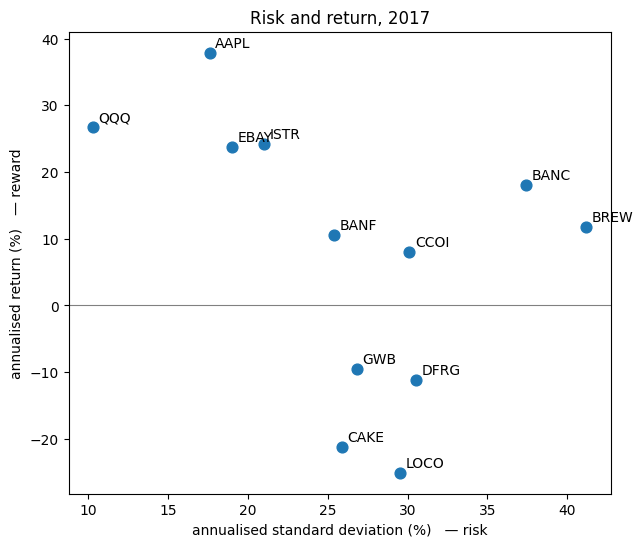

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(summary["ann. vol %"], summary["ann. return %"], s=60)
for t, row in summary.iterrows():
    plt.annotate(t, (row["ann. vol %"], row["ann. return %"]),
                 xytext=(4, 4), textcoords="offset points")
plt.axhline(0, color="grey", linewidth=0.8)
plt.xlabel("annualised standard deviation (%)   — risk")
plt.ylabel("annualised return (%)   — reward")
plt.title("Risk and return, 2017")
plt.show()

### Questions on the data

**Q1.** Which stock has the **lowest** annualised volatility of all twelve? Look up what it is in
the holdings table. Why would that kind of holding be less volatile than a single company?

> **QQQ**, at about 10% annualised volatility (the next lowest, AAPL, is about 18%). It is an ETF holding the Nasdaq-100, i.e. about 100 companies. One company's bad news is offset by the others, so the idiosyncratic risk is diversified away and only market-wide risk remains. A single stock carries all of its own company-specific risk.

**Q2.** Four of the twelve are banks. From the returns plots and the risk–return chart, would you
expect all four to move together? Write down your guess now — you will test it in Step 2.

> Not necessarily. Their returns and risk differ a lot (BANC +18% at 37% vol, GWB -10% at 27% vol, ISTR +24% at 21% vol), so I guess they do **not** all move together. My guess is that BANC/BANF/GWB (bigger regional banks) move together, while ISTR (tiny local bank) is different.

## 1f. The two tools, on something small

Before the portfolio, practise on eight credit card customers where you can see the answer with
your own eyes. The code is complete — run it and read the output.

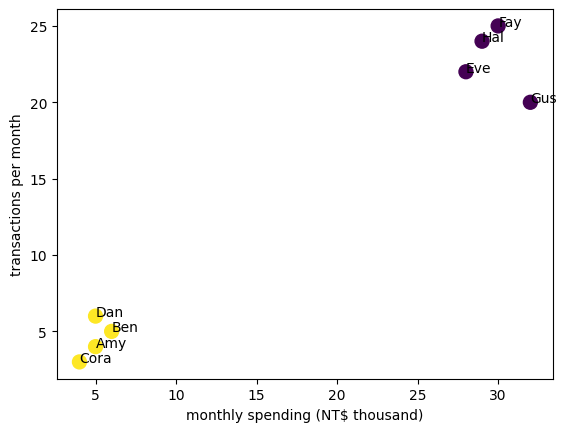

,spend,trans,kmeans
customer,,,
Amy,5,4,1
Ben,6,5,1
Cora,4,3,1
Dan,5,6,1
Eve,28,22,0
Fay,30,25,0
Gus,32,20,0
Hal,29,24,0


In [7]:
cust = pd.DataFrame({
    "customer": ["Amy", "Ben", "Cora", "Dan", "Eve", "Fay", "Gus", "Hal"],
    "spend":    [5, 6, 4, 5, 28, 30, 32, 29],   # monthly card spending, NT$ thousand
    "trans":    [4, 5, 3, 6, 22, 25, 20, 24],   # card transactions per month
}).set_index("customer")

cust["kmeans"] = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(cust)

plt.scatter(cust["spend"], cust["trans"], c=cust["kmeans"], s=100)
for name, row in cust.iterrows():
    plt.annotate(name, (row["spend"], row["trans"]))
plt.xlabel("monthly spending (NT$ thousand)"); plt.ylabel("transactions per month")
plt.show()
cust

Now the same eight customers as a **dendrogram**. Read it from the bottom up: the height at which two branches join tells you how different they are.

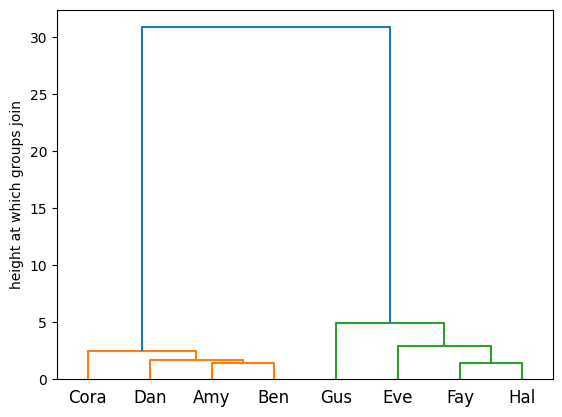

,spend,trans,kmeans,tree
customer,,,,
Amy,5,4,1,1
Ben,6,5,1,1
Cora,4,3,1,1
Dan,5,6,1,1
Eve,28,22,0,2
Fay,30,25,0,2
Gus,32,20,0,2
Hal,29,24,0,2


In [8]:
Zc = linkage(cust[["spend", "trans"]].values, method="average")
dendrogram(Zc, labels=cust.index.tolist())
plt.ylabel("height at which groups join")
plt.show()

cust["tree"] = fcluster(Zc, 2, criterion="maxclust")
cust

**Q3.** In the dendrogram, the last two groups join very high up while everything before joined
low down. What does that big jump tell you about how many groups these customers really form?

> The last merge is at a height far above all the others, so the customers form **2 real groups**: low spenders (Amy, Ben, Cora, Dan) and high spenders (Eve, Fay, Gus, Hal). Splitting into more groups would cut through a tight cluster.

**Q4.** Change `n_clusters=2` to `3` and re-run 1f. Who moves? Looking at the plot, is that a real
group or is k-means forcing one?

> With K = 3, **Gus** moves out of the high-spender group into a group of his own (the other five keep their assignment). It is not a real group: Gus (32, 20) is only slightly different from Eve/Fay/Hal, and the dendrogram shows no big gap there. K-means is forced to produce 3 groups, so it splits a cluster that is really one.

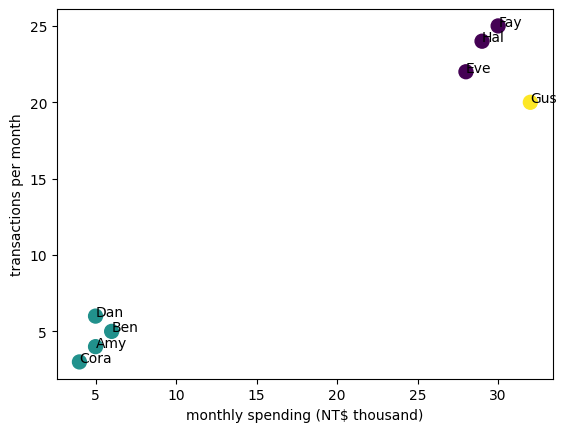

,spend,trans,kmeans,kmeans3
customer,,,,
Amy,5,4,1,1
Ben,6,5,1,1
Cora,4,3,1,1
Dan,5,6,1,1
Eve,28,22,0,0
Fay,30,25,0,0
Gus,32,20,0,2
Hal,29,24,0,0


In [9]:
# Q4 - try K = 3 here
cust["kmeans3"] = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(cust[["spend", "trans"]])
plt.scatter(cust["spend"], cust["trans"], c=cust["kmeans3"], s=100)
for name, row in cust.iterrows():
    plt.annotate(name, (row["spend"], row["trans"]))
plt.xlabel("monthly spending (NT$ thousand)"); plt.ylabel("transactions per month")
plt.show()
cust[["spend", "trans", "kmeans", "kmeans3"]]

---
# Step 2 — Cluster the portfolio (14 min)

You are clustering **stocks**, not days. Each stock must be one row, as each customer was one row.
`P` has stocks in its columns, so use `P.T` whenever you cluster stocks.

## 2a. The obvious approach (6 min)

Run **k-means with K = 3** on the price series exactly as they are. Print the members of each cluster.

In [10]:
# 2a
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(P.T)   # one row per stock, raw prices
labels_km = pd.Series(km.labels_, index=P.columns, name="cluster")
for k in range(3):
    members = labels_km[labels_km == k].index.tolist()
    print(f"Cluster {k}: {members}   mean price ~ {P[members].mean().mean():.0f}")

Cluster 0: ['BANC', 'ISTR', 'DFRG', 'LOCO', 'BREW']   mean price ~ 17
Cluster 1: ['AAPL', 'QQQ']   mean price ~ 145
Cluster 2: ['BANF', 'GWB', 'CAKE', 'EBAY', 'CCOI']   mean price ~ 44


**Q5.** Look at the industries of the stocks inside each cluster, using the holdings table.
What do the members of a cluster actually have in common? If it is nothing about the businesses,
say what it is instead. *Hint: compare with the `mean price` column of your summary table.*

> The clusters just group **share price level**, not the business. Cluster {AAPL, QQQ} are the ~$140-150 stocks. Cluster {BANF, GWB, CAKE, EBAY, CCOI} are the $35-52 stocks. Cluster {BANC, ISTR, DFRG, LOCO, BREW} are the $12-22 stocks. Each cluster mixes industries (banks are split across two clusters, and restaurants across two), which shows the grouping has nothing to do with the businesses. K-means on raw prices uses Euclidean distance, so it is dominated by the price scale.

**Q6.** Would you show these three groups to the client as his three bets? Yes / No, and why.

> **No.** The groups reflect how expensive one share is (a stock-split accident), not whether the stocks move together. They say nothing about diversification, so showing them as three bets would mislead the client.

## 2b. Cluster on what actually matters (8 min)

Two stocks belong in the same bet when they **move together**, not when they cost the same.

```python
C = R.corr()                       # how much each pair moves together
D = 1 - C                          # turn correlation into a distance
Z = linkage(squareform(D.values, checks=False), method="average")
dendrogram(Z, labels=D.columns.tolist())
```

Draw the dendrogram, then cut it into 3 groups with `fcluster`, as in Step 1.

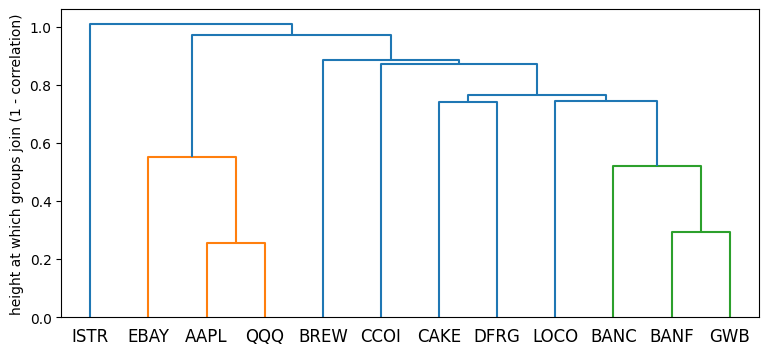

Group 1: ['AAPL', 'EBAY', 'QQQ']
Group 2: ['BANC', 'BANF', 'GWB', 'CAKE', 'DFRG', 'LOCO', 'BREW', 'CCOI']
Group 3: ['ISTR']


In [11]:
# 2b
C = R.corr()                       # how much each pair moves together
D = 1 - C                          # turn correlation into a distance
Z = linkage(squareform(D.values, checks=False), method="average")

plt.figure(figsize=(9, 4))
dendrogram(Z, labels=D.columns.tolist())
plt.ylabel("height at which groups join (1 - correlation)")
plt.show()

groups = pd.Series(fcluster(Z, 3, criterion="maxclust"), index=D.columns, name="group")
for g in sorted(groups.unique()):
    print(f"Group {g}: {groups[groups == g].index.tolist()}")

**Q7.** Write down your three groups.

> 1. **{AAPL, EBAY, QQQ}** - technology / Nasdaq.
> 2. **{ISTR}** - alone.
> 3. **{BANC, BANF, GWB, CAKE, DFRG, LOCO, BREW, CCOI}** - the domestic small-cap group (banks, restaurants, brewer, telecom).

**Q8.** Go back to your guess in Q2. Did the four banks end up together? If one of them did not,
name it — and note that this is a fact about the data, not a mistake.

> Three of them did (BANC, BANF, GWB; BANF-GWB correlation is 0.70), but **ISTR did not**. ISTR's correlation with every other stock is about zero (-0.09 to 0.10), so it forms its own group and joins last. This is a fact about the 2017 data (a very small local bank with idiosyncratic returns), not a mistake. The guess in Q2 was right for three banks and wrong for one.

---
# Step 3 — Advise the client (10 min)

**Q9.** How many independent bets does the client actually own?

> About **3 independent bets**: the tech/Nasdaq group (AAPL, EBAY, QQQ), ISTR, and the small-cap domestic group (8 stocks). The last group is only loosely correlated inside (pairs join at 0.7-0.97 distance), so the real number is somewhere between 3 and 4, but far below 12.

**Q10.** Look at AAPL and QQQ in your dendrogram, and at what QQQ is in the holdings table.
Should the client hold both? Why?

> **No.** QQQ contains AAPL (AAPL is one of its biggest holdings) and the two have correlation 0.74, the first pair to merge in the dendrogram (height 0.26). Holding both just doubles the exposure to the same bet, and QQQ already includes eBay-type tech names too. Keep one of them.

**Q11.** He wants to cut from twelve holdings to four. **Name the four you would keep**, with one
sentence of reasoning from your own dendrogram. Four tickers — he is on the phone.

> Keep: **QQQ, ISTR, BANF, CCOI**
>
> Because: one pick from each independent branch of my dendrogram: QQQ for the tech group (replaces AAPL and EBAY), ISTR because it moves independently of everything, BANF as the most typical member of the bank / small-cap group (corr 0.70 with GWB), and CCOI because it joins that group late (~0.97), so it adds a bit of extra diversification.

---
## Before the discussion

Restart & Run All, check every blank is filled, push as `IC-0921.ipynb`.

Be ready to answer out loud: **the client owns twelve stocks. Is he diversified?**